# Using ShaTS to Explain Attacks in the SWaT Dataset

This GitHub notebook demonstrates the utility of ShaTS as an explainable AI (xAI) component integrated within an anomaly detection (AD) framework using the [SWaT dataset](https://itrust.sutd.edu.sg/itrust-labs_datasets/dataset_info/). It is organized into two main sections:

- **1 - AD Framework Configuration:**  
  This section details the setup of the AD framework using the SWaT dataset, including:
  - **1.1 - Data Preprocessing:** Describes the preprocessing steps—with an emphasis on windowing techniques—that enhance the model's performance.
  - **1.2 - AD Model Training and Evaluation:** Outlines the procedures for training and evaluating the AD model.

- **2 - ShaTS xAI Module:**  
  Once the AD model is established, this section shows how ShaTS is used to generate actionable explanations for the model's predictions. The notebook provides examples of each grouping strategy:
  - **2.1 - Time Strategy:** Identifies the most critical time instant in each window that drives the model’s anomaly predictions.
  - **2.2 - Feature Strategy:** Determines the most influential feature in each time window.
  - **2.3 - Multi-Feature Strategy:** Aggregates information at the sensor/actuator level (and further at the process level) to pinpoint the primary source of anomalies.

This notebook serves as a practical guide for integrating ShaTS into an AD framework, illustrating how its various grouping strategies contribute to more coherent and actionable insights.


## 1. AD Framework Configuration

#### Imports and config

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 1.1 Data preprocessing

#### Data loading

In [3]:
path_to_dataset = '../../../../dataset/swat/SWaT_Dataset_Attack_v0.xlsx'
sheet_name = 'Combined Data'

In [4]:
dfOrig = pd.read_excel(path_to_dataset, 
                       sheet_name = sheet_name, 
                       header = 1)

/home/manuelfrancop/Escritorio/TS-SHAP/ShaTS_Patente21A/ShaTS/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


#### Data preprocessing: Windowing

In [5]:
df = dfOrig.copy()
df['Normal/Attack'] = df['Normal/Attack'].apply(lambda x: 0 if x == 'Normal' else 1).astype('category')
df['Index'] = df.index
labels = df['Normal/Attack']
data = df.drop(columns=[' Timestamp', 'Normal/Attack'])
data.head()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Index
0,2.427057,522.8467,2,2,1,262.0161,8.396437,328.6337,2.445391,2,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,0
1,2.446274,522.8860,2,2,1,262.0161,8.396437,328.6337,2.445391,2,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,1
2,2.489191,522.8467,2,2,1,262.0161,8.394514,328.6337,2.442316,2,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,2
3,2.534350,522.9645,2,2,1,262.0161,8.394514,328.6337,2.442316,2,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,3
4,2.569260,523.4748,2,2,1,262.0161,8.394514,328.6337,2.443085,2,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,4


In [6]:
segment_size = 500
padding_size = 50
train_percentage = 0.7
val_percentage = 0.15
test_percentage = 0.15

In [7]:
train_data_list, val_data_list, test_data_list, padding_data_list = [], [], [], []
train_labels_list, val_labels_list, test_labels_list, padding_labels_list = [], [], [], []
train_indexes_list, val_indexes_list, test_indexes_list, padding_indexes_list = [], [], [], []

for i in range(0, len(df), segment_size):

    init = i
    end = min(i + segment_size, len(df))

    segment_indexes = df['Index'].iloc[init:end]
    
    segment_data = data.iloc[init:end]
    segment_labels = labels.iloc[init:end]
    
    train_split_index = int(train_percentage * len(segment_data))
    val_split_index = int((train_percentage + val_percentage) * len(segment_data))
    
    #TRAIN
    train_data_list.append(segment_data.iloc[:train_split_index])
    train_labels_list.append(segment_labels.iloc[:train_split_index])
    
    # Padding before VALIDATION
    padding_start = max(0, train_split_index - padding_size)
    padding_data_list.append(segment_data.iloc[padding_start:train_split_index])
    padding_labels_list.append(segment_labels.iloc[padding_start:train_split_index])
    
    # VALIDATION
    val_data_list.append(segment_data.iloc[train_split_index:val_split_index])
    val_labels_list.append(segment_labels.iloc[train_split_index:val_split_index])
    
    # Padding before TEST
    padding_start_val = max(0, val_split_index - padding_size)
    padding_end_val = min(len(segment_data), val_split_index + padding_size)
    padding_data_list.append(segment_data.iloc[padding_start_val:val_split_index])
    padding_labels_list.append(segment_labels.iloc[padding_start_val:val_split_index])
    
    # TEST
    test_data_list.append(segment_data.iloc[val_split_index:])
    test_labels_list.append(segment_labels.iloc[val_split_index:])
    
    # Padding before next SEGMENT
    padding_end = min(len(segment_data), val_split_index + padding_size)
    padding_data_list.append(segment_data.iloc[val_split_index:padding_end])
    padding_labels_list.append(segment_labels.iloc[val_split_index:padding_end])

    train_indexes_list.append(segment_indexes.iloc[:train_split_index])
    val_indexes_list.append(segment_indexes.iloc[train_split_index:val_split_index])
    test_indexes_list.append(segment_indexes.iloc[val_split_index:])


# Concatenate
train_data = pd.concat(train_data_list).reset_index(drop=True)
val_data = pd.concat(val_data_list).reset_index(drop=True)
test_data = pd.concat(test_data_list).reset_index(drop=True)
padding_data = pd.concat(padding_data_list).reset_index(drop=True)

train_labels = pd.concat(train_labels_list).reset_index(drop=True)
val_labels = pd.concat(val_labels_list).reset_index(drop=True)
test_labels = pd.concat(test_labels_list).reset_index(drop=True)
padding_labels = pd.concat(padding_labels_list).reset_index(drop=True)

train_indexes = pd.concat(train_indexes_list).reset_index(drop=True)
val_indexes = pd.concat(val_indexes_list).reset_index(drop=True)
test_indexes = pd.concat(test_indexes_list).reset_index(drop=True)


print(f'Train data shape: {train_data.shape}')
print(f'Train labels shape: {train_labels.shape}')
print(f'Train index shape: {train_indexes.shape}')
print()

print(f'Validation data shape: {val_data.shape}')
print(f'Validation labels shape: {val_labels.shape}')
print(f'Validation index shape: {val_indexes.shape}')
print()

print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Test index shape: {test_indexes.shape}')
print()

x_train = train_data.to_numpy()
y_train = train_labels.to_numpy()
x_val = val_data.to_numpy()
y_val = val_labels.to_numpy()
x_test = test_data.to_numpy()
y_test = test_labels.to_numpy()

Train data shape: (314943, 52)
Train labels shape: (314943,)
Train index shape: (314943,)

Validation data shape: (67488, 52)
Validation labels shape: (67488,)
Validation index shape: (67488,)

Test data shape: (67488, 52)
Test labels shape: (67488,)
Test index shape: (67488,)



In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, labels, indexes, stride=1, window_size=10):

        self.x = data.to_numpy(dtype=np.float32)  
        self.labels = labels.to_numpy(dtype=np.float32)  
        self.labels = np.array([[1, 0] if label == 0 else [0, 1] for label in self.labels], dtype=np.float32)
        self.indexes = indexes.to_numpy(dtype=np.int32)  
        self.window_size = window_size
        self.stride = stride

        self.valid_idxs = self._preprocess_windows()
        self.n_idxs = len(self.valid_idxs)

    def __len__(self):
        return self.n_idxs

    def __getitem__(self, idx):
        i = self.valid_idxs[idx]
        item = {}
        item["given"] = torch.from_numpy(self.x[i:i + self.window_size]).to(torch.float32)
        item["label"] = torch.tensor(self.labels[i + self.window_size - 1], dtype=torch.float32).to(device)
        item["answer"] = torch.tensor(self.labels[i + self.window_size-1], dtype=torch.float32).to(device)
        item["indexes"] = self.indexes[i + self.window_size - 1]
        return item

    def _preprocess_windows(self):
        temp_valid_idxs = []
        total_windows = len(self.x) - self.window_size + 1
        print(f"Total windows: {total_windows}")
        
        for L in range(0, total_windows, self.stride):
            window_indices = self.indexes[L:L + self.window_size]
            
            if np.all(np.diff(window_indices) == 1):
                temp_valid_idxs.append(L)
        
        print(f"Valid windows: {len(temp_valid_idxs)}")
        return np.array(temp_valid_idxs, dtype=np.int32)

#### Data preprocessing: Removing 0-variance features, identifying continuous and categorical features

In [9]:
zero_variance_columns = train_data.columns[train_data.nunique() <= 1].tolist()

train_data_trans = train_data.drop(columns=['Index'])
val_data_trans = val_data.drop(columns=['Index'])
test_data_trans = test_data.drop(columns=['Index'])

train_data_trans = train_data_trans.drop(columns=zero_variance_columns)
val_data_trans = val_data_trans.drop(columns=zero_variance_columns)
test_data_trans = test_data_trans.drop(columns=zero_variance_columns)

categorical_columns = [col for col in train_data_trans.columns if train_data_trans[col].nunique() < 10]
continuous_columns = [col for col in train_data_trans.columns if col not in categorical_columns]

sensors = categorical_columns + continuous_columns

print(f"Zero variance columns: {len(zero_variance_columns)}: {zero_variance_columns}")
print(f'Categorical columns: {len(categorical_columns)}: {categorical_columns}')
print(f'Continuous columns: {len(continuous_columns)}: {continuous_columns}')

Zero variance columns: 7: [' P202', 'P301', 'P401', 'P404', 'P502', 'P601', 'P603']
Categorical columns: 19: [' MV101', 'P101', 'P102', ' MV201', ' P201', 'P203', ' P204', 'P205', 'P206', 'MV301', 'MV302', ' MV303', 'MV304', 'P302', 'P402', 'P403', 'UV401', 'P501', 'P602']
Continuous columns: 25: ['FIT101', 'LIT101', ' AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601']


In [10]:
for col in categorical_columns:
    train_data_trans[col] = train_data_trans[col].astype('category')
    val_data_trans[col] = val_data_trans[col].astype('category')
    test_data_trans[col] = test_data_trans[col].astype('category')

In [11]:
#Standardize continuous columns and one-hot encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)
    ]
)

pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

pipeline.fit(train_data_trans)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['FIT101', 'LIT101',
                                                   ' AIT201', 'AIT202',
                                                   'AIT203', 'FIT201',
                                                   'DPIT301', 'FIT301',
                                                   'LIT301', 'AIT401', 'AIT402',
                                                   'FIT401', 'LIT401', 'AIT501',
                                                   'AIT502', 'AIT503', 'AIT504',
                                                   'FIT501', 'FIT502', 'FIT503',
                                                   'FIT504', 'PIT501', 'PIT502',
                                                   'PIT503', 'FIT601']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [' MV101', 'P101', 'P102',
                                                   ' MV201', ' P201', 'P203',
                                                   ' P204', 'P205', 'P206',
                                                   'MV301', 'MV302', ' MV303',
                                                   'MV304', 'P302', 'P402',
                                                   'P403', 'UV401', 'P501',
                                                   'P602'])]))])

In [12]:
x_train_trans = pipeline.transform(train_data_trans)
x_val_trans = pipeline.transform(val_data_trans)
x_test_trans = pipeline.transform(test_data_trans)

In [13]:
categorical_feature_names = pipeline.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(categorical_columns)
all_feature_names = continuous_columns + list(categorical_feature_names)

x_train_df = pd.DataFrame(x_train_trans, columns=all_feature_names)
x_val_df = pd.DataFrame(x_val_trans, columns=all_feature_names)
x_test_df = pd.DataFrame(x_test_trans, columns=all_feature_names)

x_train_df.head()

,FIT101,LIT101,AIT201,AIT202,AIT203,FIT201,DPIT301,FIT301,LIT301,AIT401,...,P402_1,P402_2,P403_1,P403_2,UV401_1,UV401_2,P501_1,P501_2,P602_1,P602_2
0,0.599851,-0.672078,1.470969,-1.170701,0.500734,0.657637,0.507553,0.543890,0.571288,0.549771,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.615963,-0.671764,1.470969,-1.170701,0.500734,0.657637,0.507553,0.545442,0.571288,0.549771,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.651945,-0.672078,1.470969,-1.187723,0.500734,0.654918,0.500114,0.545865,0.575259,0.549771,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,0.689807,-0.671138,1.470969,-1.187723,0.500734,0.654918,0.500114,0.545865,0.579231,0.549771,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,0.719076,-0.667064,1.470969,-1.187723,0.500734,0.655598,0.500114,0.545865,0.582707,0.549771,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [14]:
print(f"Train data transformed shape: {x_train_df.shape}")
print(f"Validation data transformed shape: {x_val_df.shape}")
print(f"Test data transformed shape: {x_test_df.shape}")

variable_names = all_feature_names
print("Variables names after transformation:")
print(variable_names)

Train data transformed shape: (314943, 69)
Validation data transformed shape: (67488, 69)
Test data transformed shape: (67488, 69)
Variables names after transformation:
['FIT101', 'LIT101', ' AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601', ' MV101_0', ' MV101_1', ' MV101_2', 'P101_1', 'P101_2', 'P102_1', 'P102_2', ' MV201_0', ' MV201_1', ' MV201_2', ' P201_1', ' P201_2', 'P203_1', 'P203_2', ' P204_1', ' P204_2', 'P205_1', 'P205_2', 'P206_1', 'P206_2', 'MV301_0', 'MV301_1', 'MV301_2', 'MV302_0', 'MV302_1', 'MV302_2', ' MV303_0', ' MV303_1', ' MV303_2', 'MV304_0', 'MV304_1', 'MV304_2', 'P302_1', 'P302_2', 'P402_1', 'P402_2', 'P403_1', 'P403_2', 'UV401_1', 'UV401_2', 'P501_1', 'P501_2', 'P602_1', 'P602_2']


In [15]:
trainDataset = TimeSeriesDataset(data=pd.DataFrame(x_train_df) , labels=train_labels, indexes=train_indexes , stride=1, window_size=10)
valDataset = TimeSeriesDataset(data=pd.DataFrame(x_val_df) , labels=val_labels, indexes=val_indexes , stride=1, window_size=10)
testDataset = TimeSeriesDataset(data=pd.DataFrame(x_test_df) , labels=test_labels, indexes=test_indexes , stride=1, window_size=10)

Total windows: 314934
Valid windows: 306843
Total windows: 67479
Valid windows: 59388
Total windows: 67479
Valid windows: 59388


In [16]:
variables_map = {}

#Continuous variables
for v in continuous_columns:
    variables_map[v] = [all_feature_names.index(v)]  

#Categorical variables
encoder = pipeline.named_steps["preprocessor"].transformers_[1][1] 
for v, categories in zip(categorical_columns, encoder.categories_):
    encoded_names = [f"{v}_{category}" for category in categories]
    indexes = [all_feature_names.index(name) for name in encoded_names]
    variables_map[v] = indexes

print("Variables map:")
for k, v in variables_map.items():
    print(f"{k}: {v}")

Variables map:
FIT101: [0]
LIT101: [1]
 AIT201: [2]
AIT202: [3]
AIT203: [4]
FIT201: [5]
DPIT301: [6]
FIT301: [7]
LIT301: [8]
AIT401: [9]
AIT402: [10]
FIT401: [11]
LIT401: [12]
AIT501: [13]
AIT502: [14]
AIT503: [15]
AIT504: [16]
FIT501: [17]
FIT502: [18]
FIT503: [19]
FIT504: [20]
PIT501: [21]
PIT502: [22]
PIT503: [23]
FIT601: [24]
 MV101: [25, 26, 27]
P101: [28, 29]
P102: [30, 31]
 MV201: [32, 33, 34]
 P201: [35, 36]
P203: [37, 38]
 P204: [39, 40]
P205: [41, 42]
P206: [43, 44]
MV301: [45, 46, 47]
MV302: [48, 49, 50]
 MV303: [51, 52, 53]
MV304: [54, 55, 56]
P302: [57, 58]
P402: [59, 60]
P403: [61, 62]
UV401: [63, 64]
P501: [65, 66]
P602: [67, 68]


### 1.2 AD Model Training and Evaluation

#### AD Model definition

In [17]:
class StackedLSTM(torch.nn.Module):

    def __init__(self, n_tags, n_classes, hidden_size=64, num_layers=3, bidirectional=True, dropout=0):
        super().__init__()
        self.rnn = torch.nn.LSTM(
            input_size=n_tags,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            dropout=dropout,
        )
        self.fc = torch.nn.Linear(2*hidden_size if bidirectional else hidden_size, n_classes)

    def forward(self, x):
        x = x.transpose(0, 1)
        self.rnn.flatten_parameters()
        outs, _ = self.rnn(x)
        out = self.fc(outs[-1])
        return out

#### Training/Loading the AD model

In [18]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)  
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Optimal hyperparameters
input_dim = trainDataset[0]['given'].shape[1]
hidden_dim = 32
num_layers = 2
dropout = 0.2
num_classes = 2
learning_rate = 0.001
num_epochs = 5
batch_size = 2048
alpha = 1
gamma = 2


model = StackedLSTM(n_tags=input_dim, n_classes=num_classes, hidden_size=hidden_dim, num_layers=num_layers).to(device)
criterion = FocalLoss(alpha=alpha, gamma=gamma)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


train_loader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valDataset, batch_size=batch_size, shuffle=False)

trainBool = False
if trainBool:

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for data_batch in train_loader:
            x_batch = data_batch["given"].to(device)
            y_batch = data_batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            y_batch_indices = torch.argmax(y_batch, dim=1)            
            loss = criterion(outputs, y_batch_indices)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_loss:.4f}')

        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for data_batch in val_loader:
                x_batch = data_batch["given"].to(device)
                y_batch = data_batch["label"].to(device)
                outputs = model(x_batch)
                y_batch_indices = torch.argmax(y_batch, dim=1)
                predicted = torch.argmax(outputs, dim=1)
                loss = criterion(outputs, y_batch_indices)
                val_loss += loss.item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(y_batch_indices.cpu().numpy())

        val_loss /= len(val_loader)

        all_preds = np.array(all_preds).reshape(-1)
        all_labels = np.array(all_labels).reshape(-1)

        accuracy = (all_preds == all_labels).mean()
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        print(f'Validation Loss: {val_loss:.4f} | Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}\n')

    torch.save(model.state_dict(), 'ADmodel.pt')

else:
    model.load_state_dict(torch.load('ADmodel.pt'))

#### Model evaluation

Test Accuracy: 0.9782 | Precision: 0.9718 | Recall: 0.9259 | F1-score: 0.9473



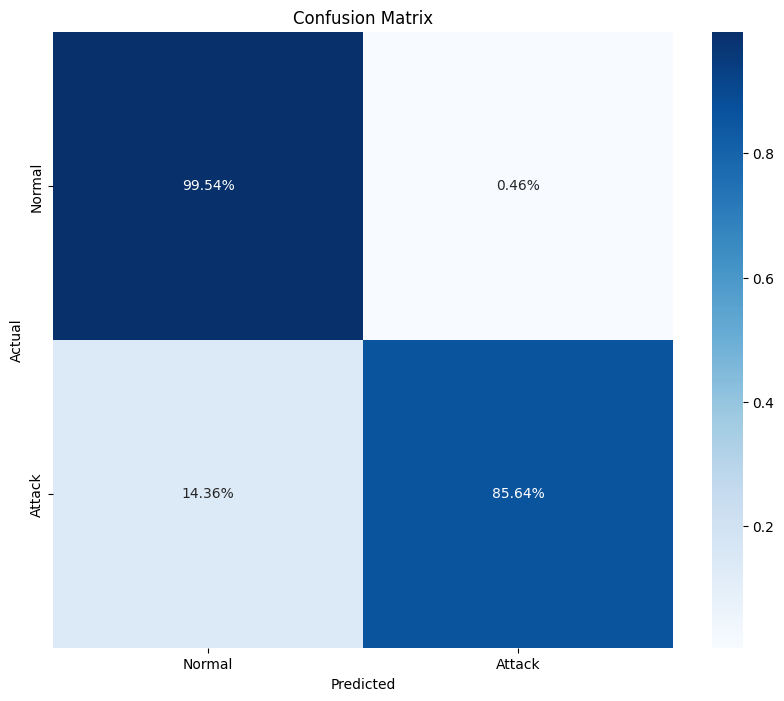

In [19]:
model.eval()
test_loader = DataLoader(testDataset, batch_size=batch_size, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for data_batch in test_loader:
        x_batch = data_batch["given"].to(device)
        y_batch = data_batch["label"].to(device)
        outputs = model(x_batch)
        y_batch_indices = torch.argmax(y_batch, dim=1)
        predicted = torch.argmax(outputs, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch_indices.cpu().numpy())

all_preds = np.array(all_preds).reshape(-1)
all_labels = np.array(all_labels).reshape(-1)

accuracy = (all_preds == all_labels).mean()
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f'Test Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}\n')

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm / cm.sum(axis=1)[:, np.newaxis], annot=True, fmt='.2%', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Creation of a wrapper of the model that compute the probs of each class

In [20]:
def model_probs(model):

    def f(data):    
        model.eval()
        with torch.no_grad():
            #check if the batch size is 1
            if len(data.shape) == 2:
                data = data.unsqueeze(0)
            data = data.to(device)  # data shape: [batch_size, ...]
            outputs = model(data)   # outputs shape: [batch_size, num_classes]
            probabilities = torch.softmax(outputs, dim=1)
            return probabilities
    return f

model_wrapper = model_probs(model)

## 2 - ShaTS xAI Component

#### Configuration

In [21]:
import os
import sys
sys.path.append(os.path.abspath("../../src"))

import shats
from shats.grouping import TimeGroupingStrategy, MultifeaturesGroupingStrategy, FeaturesGroupingStrategy

#### Creation of the background dataset and selection of the windows that will be explained 

In [22]:
random_samples = random.sample(range(len(trainDataset)), 100)
background = [trainDataset[idx]['given'] for idx in random_samples]

begin = 190 #begining instant to be explained
end = begin + 100 #end instant to be explained
test = [testDataset[idx]['given'] for idx in range(begin, end)]

### 2.1 - ShaTS Temporal Strategy

In this strategy, all feature values corresponding to each individual time instant within a window are grouped together, allowing ShaTS to reveal which specific points in time exert the greatest influence on the model’s anomaly predictions. This grouping is particularly useful for highlighting critical moments—such as the onset or end of an attack—within a time window.

Below is a brief example of how to employ the temporal grouping strategy using ShaTS

Processing item 100/100 (100.00%)

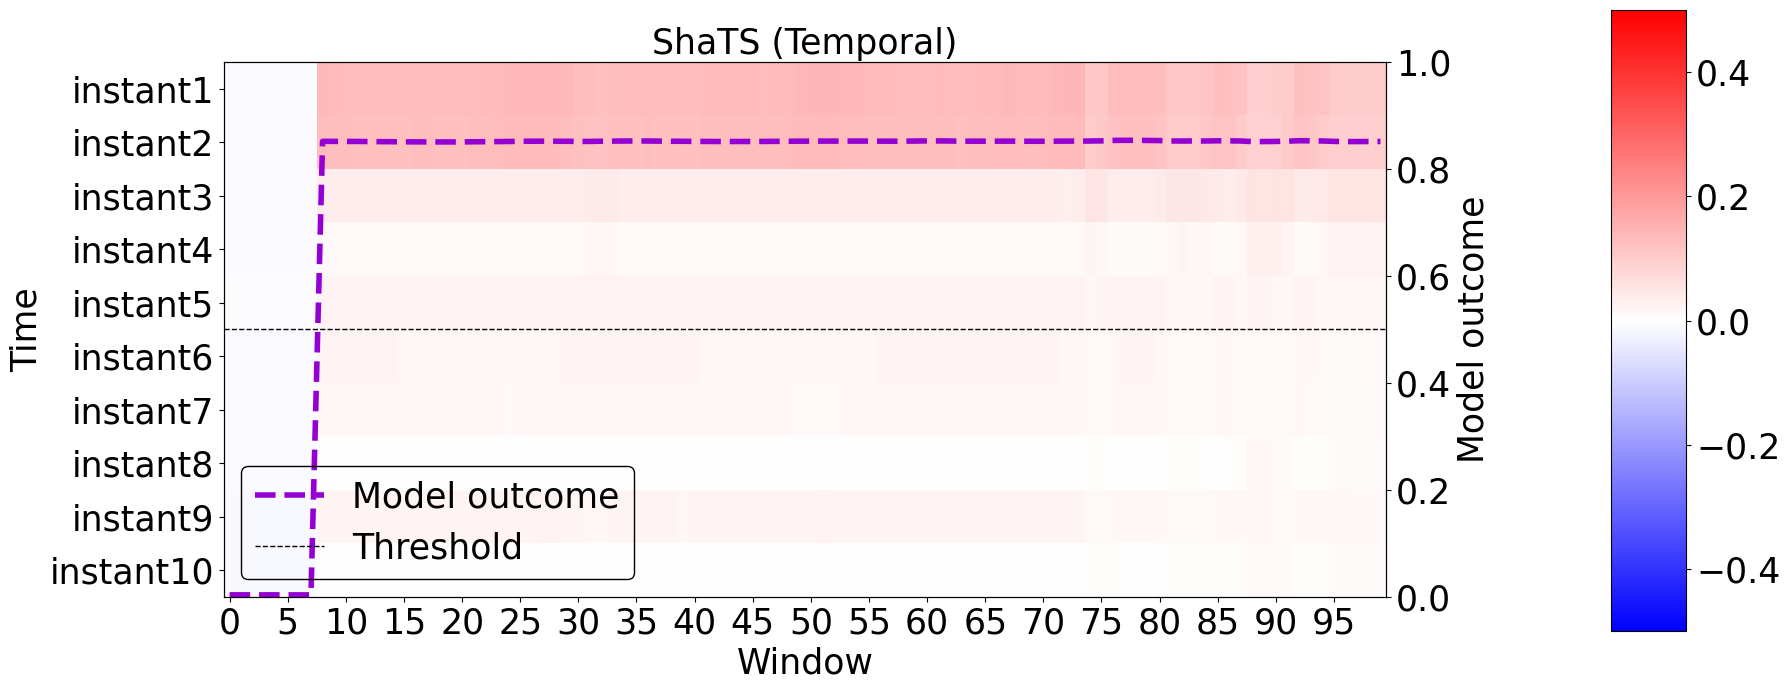

In [23]:
shapley_class = shats.FastShaTS(model_wrapper, 
                               background_dataset=background ,
                               grouping_strategy= "time"
                               )

shapley_values = shapley_class.compute(test)

shapley_class.plot(shapley_values, test, class_to_explain=1)

### 2.2 - ShaTS Feature Strategy

In this strategy, individual features are grouped across time, allowing each feature's contribution to be evaluated independently within a time window. This approach enables the identification of which specific features are most influential in driving the model’s predictions.

Processing item 100/100 (100.00%)

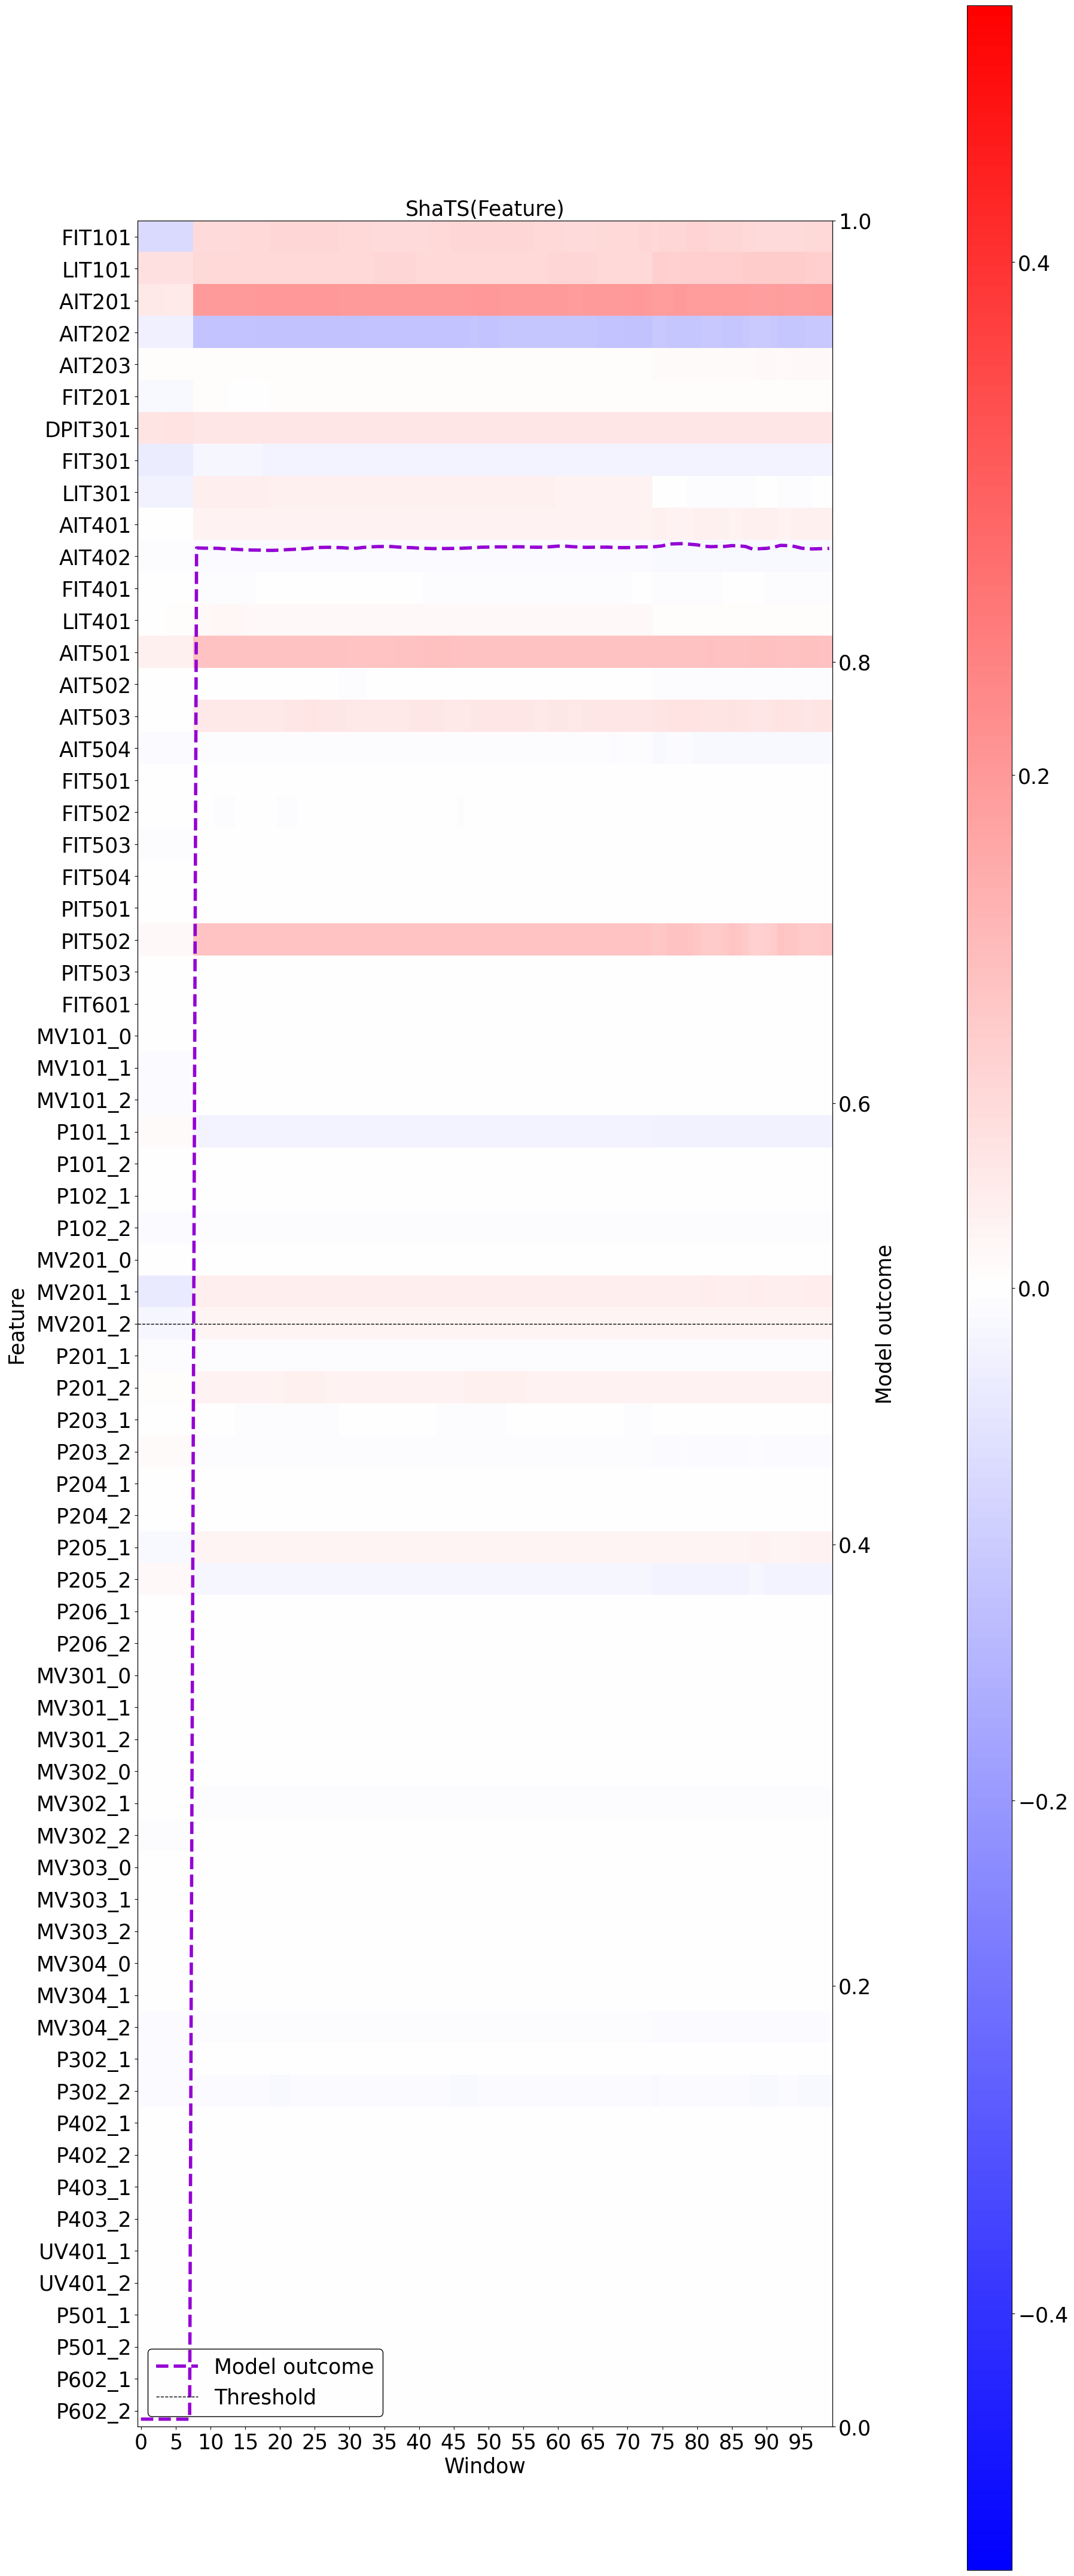

In [24]:
shapley_class = shats.FastShaTS(model_wrapper, 
                               background_dataset=background ,
                               grouping_strategy= FeaturesGroupingStrategy(names=variable_names),
                               )

shapley_values = shapley_class.compute(test)
shapley_class.plot(shapley_values, test, class_to_explain=1)

### 2.3 - ShaTS MultiFeature Strategy

The feature strategy is effective at highlighting the importance of individual features within a time window. However, when several features essentially represent the same underlying aspect—such as multiple one-hot encoded variables for a single categorical measurement or several features corresponding to the same sensor/actuator or industrial process—a multi-feature strategy proves more beneficial. This approach aggregates related features into one group, providing a clearer and more consolidated interpretation of their collective influence.

Two examples illustrate this strategy:
- **Sensor/Actuator Grouping:** Grouping features associated with the same physical device helps identify that sensor or actuator as the key contributor to an anomaly. This reduces fragmentation in the explanation and offers actionable insights at the device level.
- **Industrial Process Grouping:** When multiple features pertain to the same industrial process, aggregating them helps pinpoint the process affected by an anomaly, facilitating a higher-level interpretation that is critical for diagnosing and mitigating operational issues.

By capturing the collective effect of related features, ShaTS delivers more coherent and actionable insights compared to treating each feature independently.

#### Sensor/Actuator Grouping

In [25]:
variables_map_idxs_array = []
for key, value in variables_map.items():
    variables_map_idxs_array.append(value)

Processing item 100/100 (100.00%)

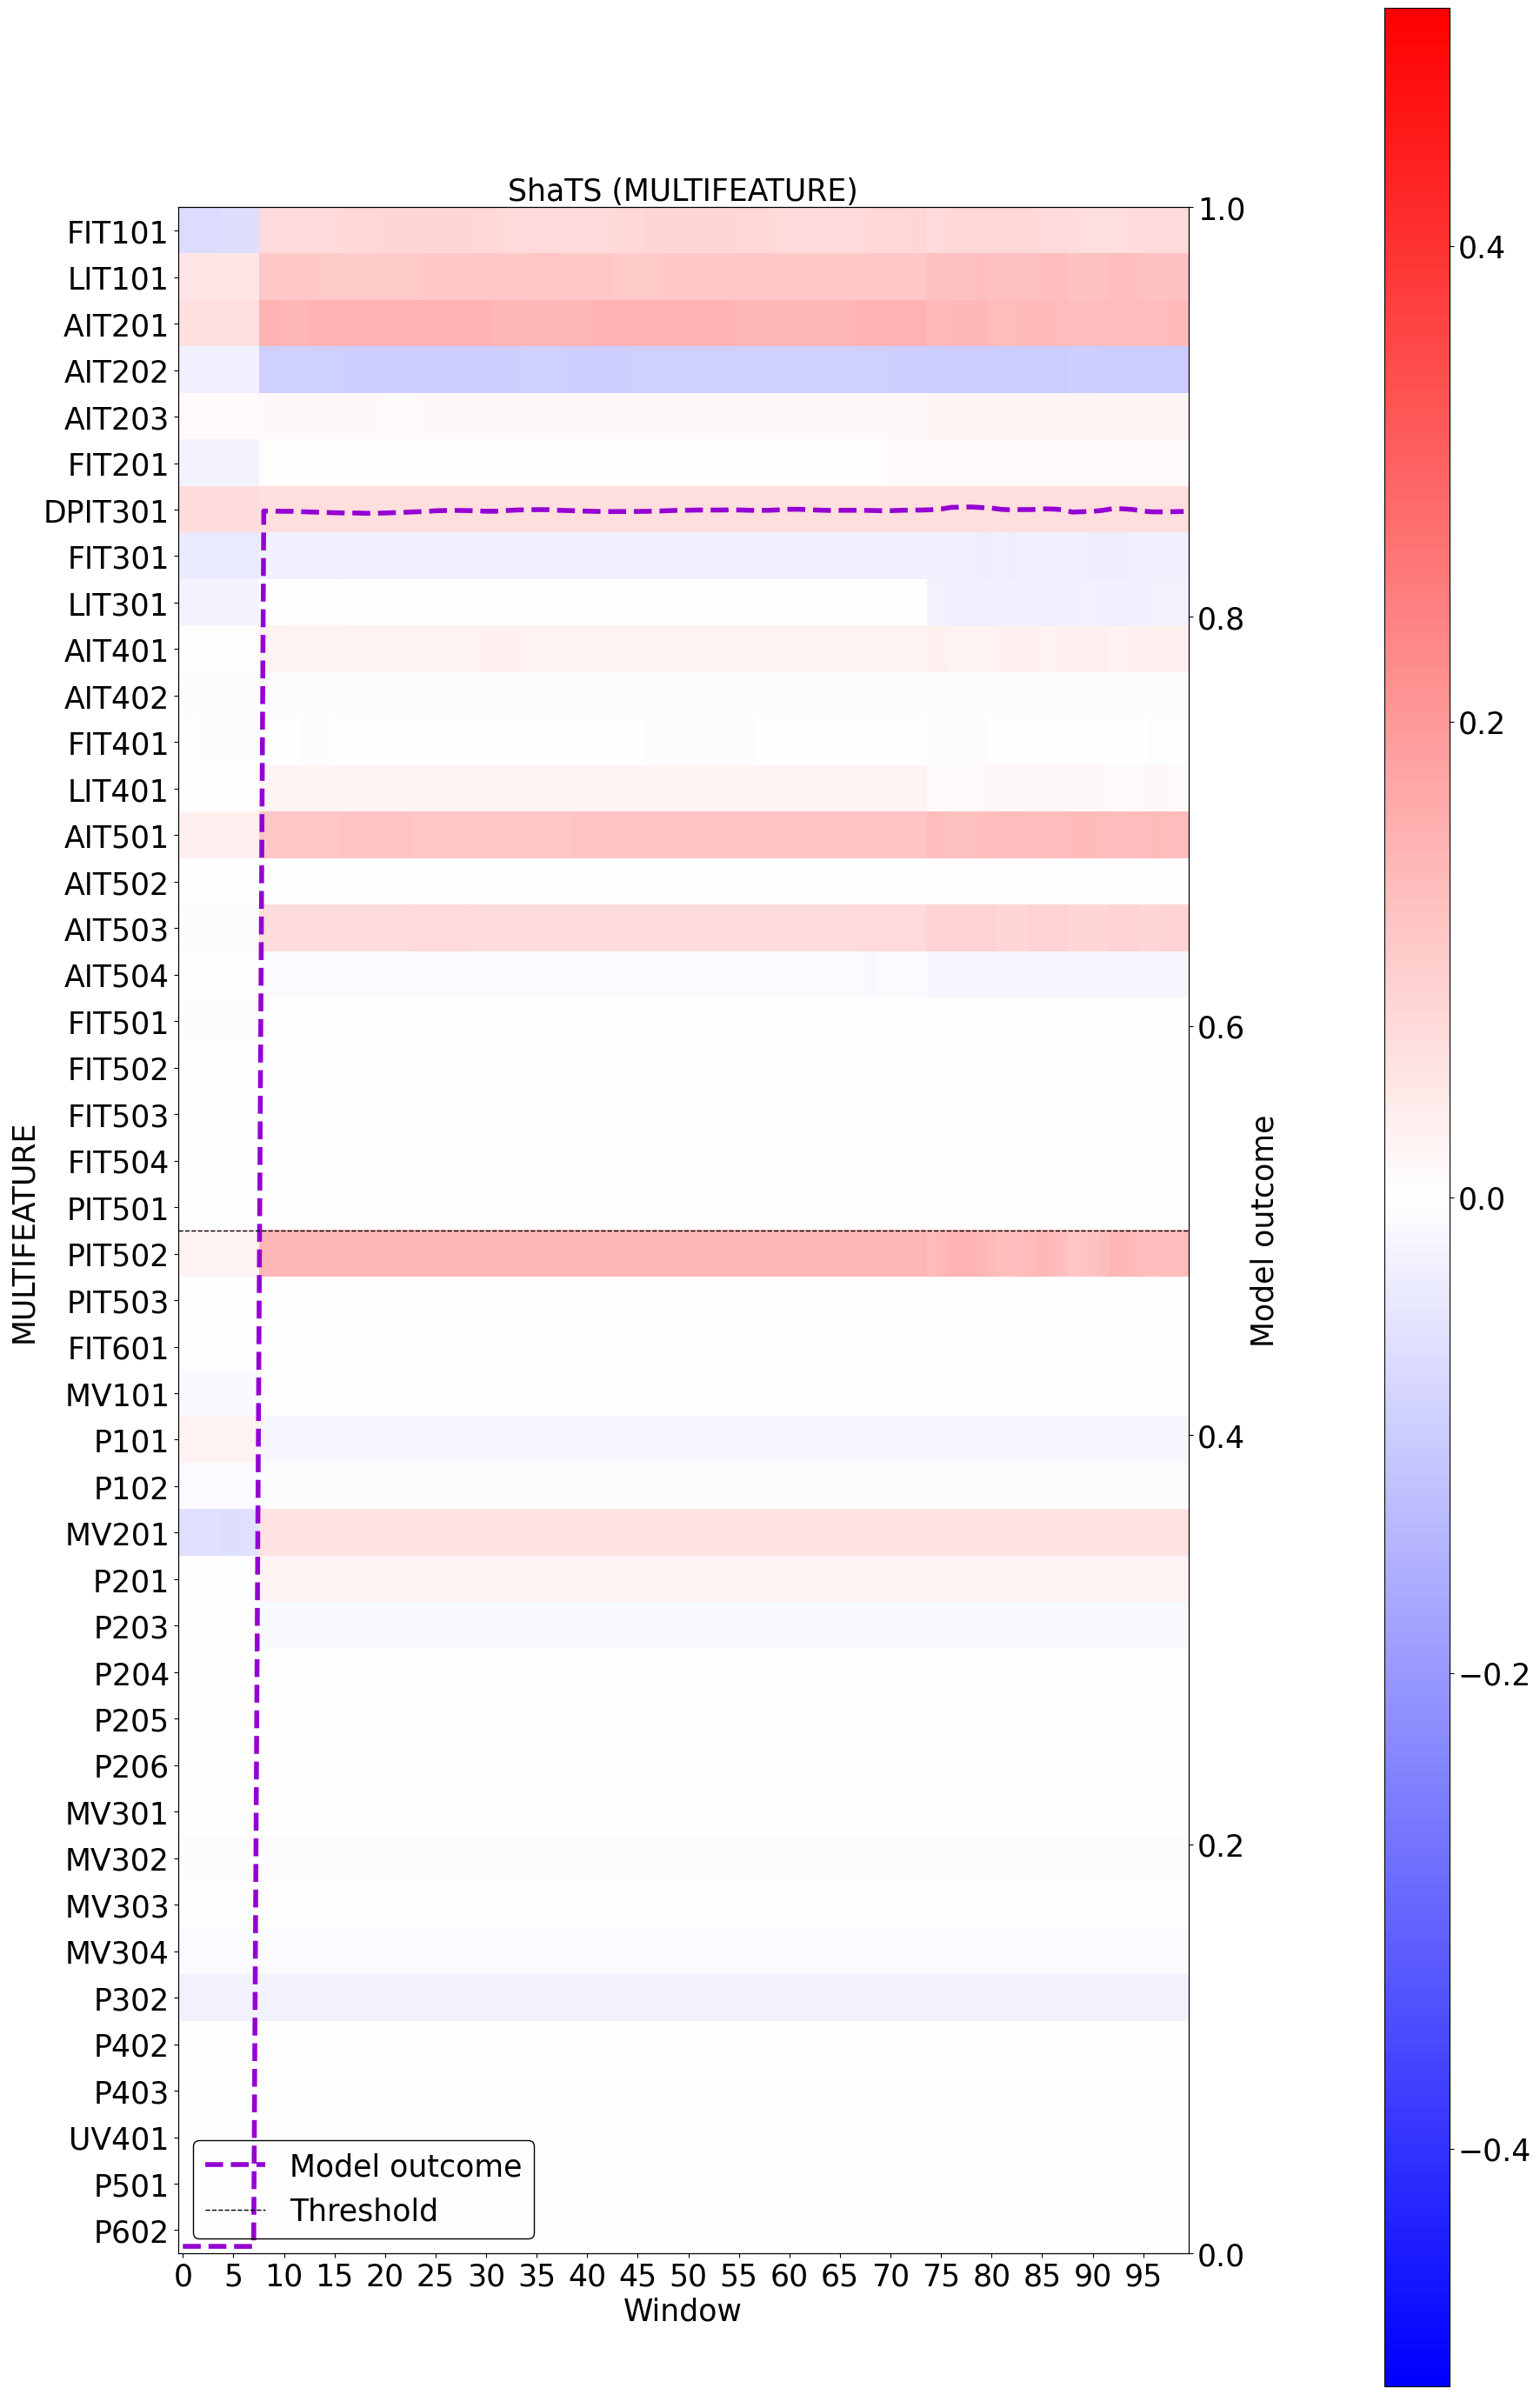

In [26]:
shapley_class = shats.FastShaTS(model_wrapper, 
                               background_dataset=background ,
                               grouping_strategy= MultifeaturesGroupingStrategy(groups_num=len(variables_map_idxs_array),
                                                                                custom_groups=variables_map_idxs_array, 
                                                                                names= list(variables_map.keys())),
                               )

shapley_values = shapley_class.compute(test)
shapley_class.plot(shapley_values, test ,class_to_explain=1)

#### Process Grouping

In [27]:
swat_process = [
    # P1
    [0, 1, 2, 3, 4],  # FIT101, LIT101, MV101, P101, P102
    
    # P2
    [5, 6, 7, 8, 9, 10, 11, 12, 13, 14],  # AIT201, AIT202, AIT203, FIT201, MV201, P201, P203, P204, P205, P206
    
    # P3
    [15, 16, 17, 18, 19, 20, 21, 22],  # DPIT301, FIT301, LIT301, MV301, MV302, MV303, MV304, P302
    
    # P4 
    [23, 24, 25, 26, 27, 28, 29],  # AIT401, AIT402, FIT401, LIT401, P402, P403, UV401
    
    # P5
    [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41],  # AIT501, AIT502, AIT503, AIT504, FIT501, FIT502, FIT503, FIT504, P501, PIT501, PIT502, PIT503
    
    # P6
    [42,43]  # FIT601, p602
]

Processing item 100/100 (100.00%)

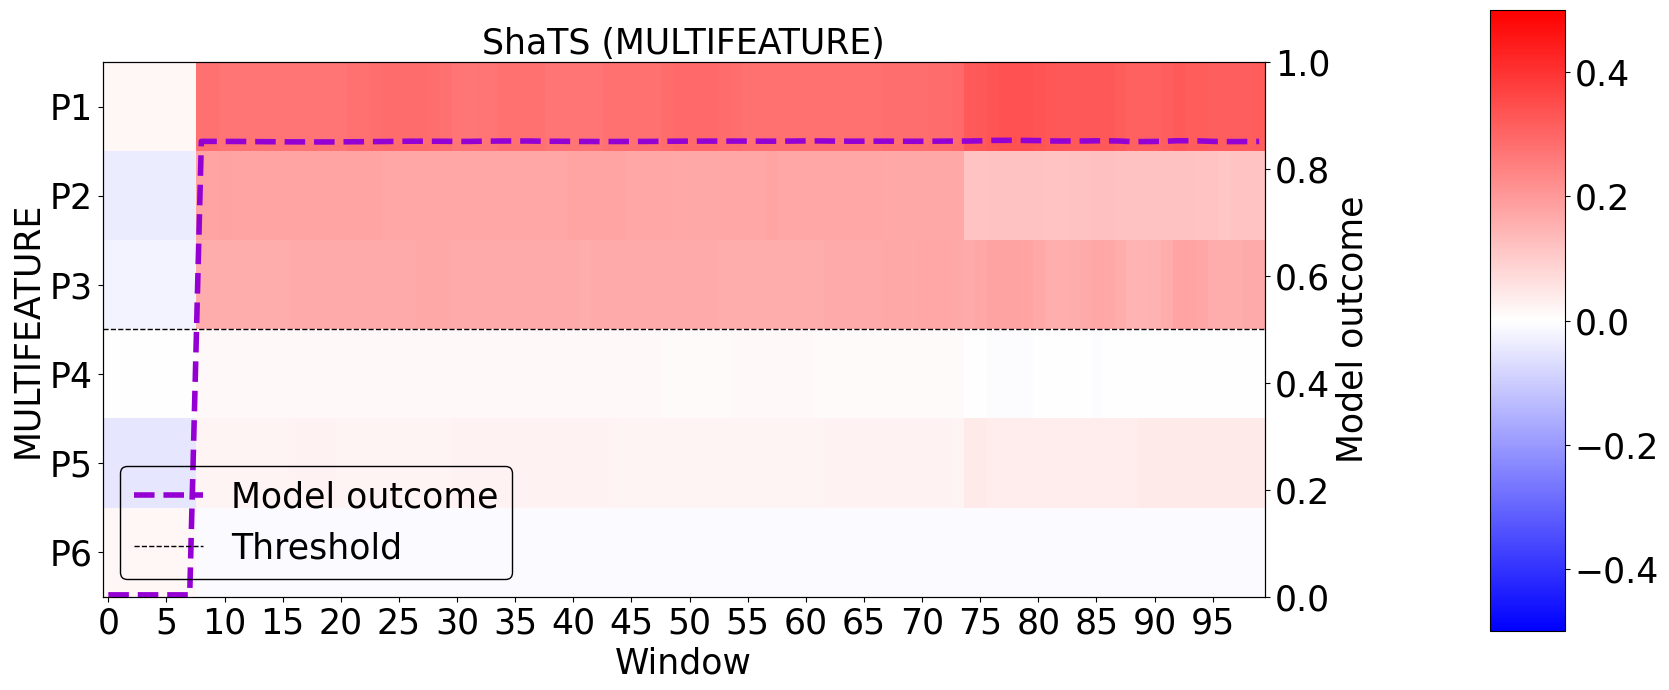

In [28]:
shapley_class = shats.FastShaTS(model_wrapper, 
                               background_dataset=background ,
                               grouping_strategy= MultifeaturesGroupingStrategy(custom_groups=swat_process, 
                                                                                names= ['P1', 'P2', 'P3', 'P4', 'P5', 'P6'])
                               )


shapley_values = shapley_class.compute(test)

shapley_class.plot(shapley_values, test, class_to_explain=1)